#📌 Extracão

In [56]:
import pandas as pd

In [57]:
url = 'https://raw.githubusercontent.com/SilasTeodoro/Challenge-TelecomX/refs/heads/main/TelecomX_Data.json'

In [58]:
df = pd.read_json(url)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformação

In [59]:
# Normalizar as colunas
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

# Teste do normalize
#df_customer.head()
#df_phone.head()
#df_internet.head()
#df_account.head()

In [60]:
# Concatenar todas as colunas normalizadas e fazer uma única tabela com todos os dados
df_normalized = pd.concat([df[['customerID', 'Churn']], df_customer, df_phone, df_internet, df_account], axis=1)
df_normalized.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [61]:
df_normalized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [62]:
#Verificando valores nulos no dataframe
print("Valores Nulos por Coluna:\n", df_normalized.isnull().sum())

Valores Nulos por Coluna:
 customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


In [63]:
# Verificando se há linhas duplicadas
print('Número de Valores Duplicados', df_normalized.duplicated().sum())

Número de Valores Duplicados 0


In [64]:
# Verificando se há valores em branco
df_normalized.apply(lambda x: x.astype(str).str.strip() == '').sum()

,0
customerID,0
Churn,224
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [65]:
# Tranformando o tipo de dados da coluna "Charges.Total" de object para float
df_normalized['Charges.Total'] = pd.to_numeric(df_normalized['Charges.Total'], errors='coerce')
df_normalized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [66]:
import numpy as np

# Tratar os valores nulos de "Charges.Total"
# Calculando a mediana da coluna "Charges.Total"
median_charges_total = df_normalized['Charges.Total'].median()

# Aplicando a mediana nas linhas que foram atribuídas NaN quando convertemos o tipo do dados
df_normalized['Charges.Total'].fillna(median_charges_total, inplace=True)


# Tratar Valores Vazios e Converter 'Churn'
# Converter valores em branco da coluna 'Churn' para NaN
df_normalized['Churn'] = df_normalized['Churn'].replace(r'^\s*$', np.nan, regex=True)

# Preencher esses NaN com o valor mais frequente (moda) da coluna 'Churn'
mode_churn = df_normalized['Churn'].mode()[0]
df_normalized['Churn'].fillna(mode_churn, inplace=True)

# Garantir que a coluna 'Churn' seja do tipo 'category'
df_normalized['Churn'] = df_normalized['Churn'].astype('category')

# Verificar o Tratamento dos Valores
# Exibir o info() do DataFrame df_normalized novamente para confirmar as alterações
print("\nDataFrame info após tratamento de valores vazios:")
df_normalized.info()

print("\nVerificação de valores em branco após tratamento:")
print(df_normalized.apply(lambda x: x.astype(str).str.strip() == '').sum())


DataFrame info após tratamento de valores vazios:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7267 non-null   object  
 1   Churn             7267 non-null   category
 2   gender            7267 non-null   object  
 3   SeniorCitizen     7267 non-null   int64   
 4   Partner           7267 non-null   object  
 5   Dependents        7267 non-null   object  
 6   tenure            7267 non-null   int64   
 7   PhoneService      7267 non-null   object  
 8   MultipleLines     7267 non-null   object  
 9   InternetService   7267 non-null   object  
 10  OnlineSecurity    7267 non-null   object  
 11  OnlineBackup      7267 non-null   object  
 12  DeviceProtection  7267 non-null   object  
 13  TechSupport       7267 non-null   object  
 14  StreamingTV       7267 non-null   object  
 15  StreamingMovies   726

/tmp/ipykernel_350/686231558.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_normalized['Charges.Total'].fillna(median_charges_total, inplace=True)
/tmp/ipykernel_350/686231558.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


In [67]:
# Criando nova coluna "Contas_Diarias" com base no faturamento mensal
# 30,4375 é a média de dias por mês considerando também o ano bissexto
df_normalized['Contas_Diarias'] = df_normalized['Charges.Monthly'] / 30.4375
df_normalized.info()
df_normalized.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7267 non-null   object  
 1   Churn             7267 non-null   category
 2   gender            7267 non-null   object  
 3   SeniorCitizen     7267 non-null   int64   
 4   Partner           7267 non-null   object  
 5   Dependents        7267 non-null   object  
 6   tenure            7267 non-null   int64   
 7   PhoneService      7267 non-null   object  
 8   MultipleLines     7267 non-null   object  
 9   InternetService   7267 non-null   object  
 10  OnlineSecurity    7267 non-null   object  
 11  OnlineBackup      7267 non-null   object  
 12  DeviceProtection  7267 non-null   object  
 13  TechSupport       7267 non-null   object  
 14  StreamingTV       7267 non-null   object  
 15  StreamingMovies   7267 non-null   object  
 16  Contract          7267 n

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.155236
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.967967
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.427926
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.219713
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.756468


In [68]:
# Renomeando os nomes das colunas
novos_nomes_colunas = {                                                                # Dicionário com os novos nomes das colunas.
    'customerID': 'ID',
    'gender': 'Genero',
    'SeniorCitizen': 'Idoso_60+',
    'Partner': 'Possui_Parceiro',
    'Dependents': 'Possui_Dependentes',
    'tenure': 'Tempo_Contrato',
    'PhoneService': 'Servico_Telefone',
    'MultipleLines': 'Multiplas_Linhas',
    'InternetService': 'Servico_Internet',
    'OnlineSecurity': 'Seguranca_Online',
    'OnlineBackup': 'Backup_Online',
    'DeviceProtection': 'Protecao_Dispositivo',
    'TechSupport': 'Suporte_Tecnico',
    'StreamingTV': 'Streaming_tv',
    'StreamingMovies': 'Streaming_Filmes',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Fatura_Digital',
    'PaymentMethod': 'Metodo_Pagamento',
    'Charges.Monthly': 'Cobranca_Mensal',
    'Charges.Total': 'Cobranca_Total'
}

df_normalized = df_normalized.rename(columns=novos_nomes_colunas)
df_normalized.columns
df_normalized.info()
df_normalized.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   ID                    7267 non-null   object  
 1   Churn                 7267 non-null   category
 2   Genero                7267 non-null   object  
 3   Idoso_60+             7267 non-null   int64   
 4   Possui_Parceiro       7267 non-null   object  
 5   Possui_Dependentes    7267 non-null   object  
 6   Tempo_Contrato        7267 non-null   int64   
 7   Servico_Telefone      7267 non-null   object  
 8   Multiplas_Linhas      7267 non-null   object  
 9   Servico_Internet      7267 non-null   object  
 10  Seguranca_Online      7267 non-null   object  
 11  Backup_Online         7267 non-null   object  
 12  Protecao_Dispositivo  7267 non-null   object  
 13  Suporte_Tecnico       7267 non-null   object  
 14  Streaming_tv          7267 non-null   object  
 15  Stre

,ID,Churn,Genero,Idoso_60+,Possui_Parceiro,Possui_Dependentes,Tempo_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_tv,Streaming_Filmes,Contrato,Fatura_Digital,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Total,Contas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.155236
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.967967
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.427926
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.219713
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.756468


In [69]:
# Padronizando os valores das linhas

df_normalized['Idoso_60+'] = df_normalized['Idoso_60+'].astype(str)
df_normalized.info()
df_normalized['Churn'] = df_normalized['Churn'].replace({'No': 'Não', 'Yes': 'Sim'})
df_normalized['Genero'] = df_normalized['Genero'].replace({'Female': 'Feminino', 'Male': 'Masculino'})
df_normalized['Idoso_60+'] = df_normalized['Idoso_60+'].replace({'0':'Não','1':'Sim'})
df_normalized['Possui_Parceiro'] = df_normalized['Possui_Parceiro'].replace({'Yes': 'Sim', 'No': 'Não'})
df_normalized['Possui_Dependentes'] = df_normalized['Possui_Dependentes'].replace({'Yes': 'Sim', 'No': 'Não'})
df_normalized['Servico_Telefone'] = df_normalized['Servico_Telefone'].replace({'Yes': 'Sim', 'No': 'Não'})
df_normalized['Multiplas_Linhas'] = df_normalized['Multiplas_Linhas'].replace({'No': 'Não', 'Yes': 'Sim', 'No phone service': 'Sem serviço de telefone'})
df_normalized['Servico_Internet'] = df_normalized['Servico_Internet'].replace({'Fiber optic': 'Fibra optica', 'No': 'Não'})
df_normalized['Contrato'] = df_normalized['Contrato'].replace({'One year': 'Um Ano', 'Month-to-month': 'Mensal', 'Two year':'Dois Anos'})
df_normalized['Protecao_Dispositivo'] = df_normalized['Protecao_Dispositivo'].replace({'Yes': 'Sim', 'No': 'Não'})
df_normalized['Suporte_Tecnico'] = df_normalized['Suporte_Tecnico'].replace({'Yes': 'Sim', 'No': 'Não'})
df_normalized['Streaming_tv'] = df_normalized['Streaming_tv'].replace({'Yes': 'Sim', 'No': 'Não'})
df_normalized['Streaming_Filmes'] = df_normalized['Streaming_Filmes'].replace({'Yes': 'Sim', 'No': 'Não'})
df_normalized['Fatura_Digital'] = df_normalized['Fatura_Digital'].replace({'Yes': 'Sim', 'No': 'Não'})
df_normalized['Seguranca_Online'] = df_normalized['Seguranca_Online'].replace({'Yes': 'Sim', 'No': 'Não', 'No internet service': 'Sem Servico de Internet'})
df_normalized['Backup_Online'] = df_normalized['Backup_Online'].replace({'Yes': 'Sim', 'No': 'Não', 'No internet service': 'Sem Servico de Internet'})
df_normalized['Metodo_Pagamento'] = df_normalized['Metodo_Pagamento'].replace({
    'Mailed check': 'Cheque Enviado','Electronic check': 'Cheque eletrônico',
    'Credit card (automatic)': 'Cartão de crédito (automático)','Bank transfer (automatic)': 'Transferência bancária (automática)'})

df_normalized

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   ID                    7267 non-null   object  
 1   Churn                 7267 non-null   category
 2   Genero                7267 non-null   object  
 3   Idoso_60+             7267 non-null   object  
 4   Possui_Parceiro       7267 non-null   object  
 5   Possui_Dependentes    7267 non-null   object  
 6   Tempo_Contrato        7267 non-null   int64   
 7   Servico_Telefone      7267 non-null   object  
 8   Multiplas_Linhas      7267 non-null   object  
 9   Servico_Internet      7267 non-null   object  
 10  Seguranca_Online      7267 non-null   object  
 11  Backup_Online         7267 non-null   object  
 12  Protecao_Dispositivo  7267 non-null   object  
 13  Suporte_Tecnico       7267 non-null   object  
 14  Streaming_tv          7267 non-null   object  
 15  Stre

/tmp/ipykernel_350/1479709418.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_normalized['Churn'] = df_normalized['Churn'].replace({'No': 'Não', 'Yes': 'Sim'})


,ID,Churn,Genero,Idoso_60+,Possui_Parceiro,Possui_Dependentes,Tempo_Contrato,Servico_Telefone,Multiplas_Linhas,Servico_Internet,...,Protecao_Dispositivo,Suporte_Tecnico,Streaming_tv,Streaming_Filmes,Contrato,Fatura_Digital,Metodo_Pagamento,Cobranca_Mensal,Cobranca_Total,Contas_Diarias
0,0002-ORFBO,Não,Feminino,Não,Sim,Sim,9,Sim,Não,DSL,...,Não,Sim,Sim,Não,Um Ano,Sim,Cheque Enviado,65.60,593.30,2.155236
1,0003-MKNFE,Não,Masculino,Não,Não,Não,9,Sim,Sim,DSL,...,Não,Não,Não,Sim,Mensal,Não,Cheque Enviado,59.90,542.40,1.967967
2,0004-TLHLJ,Sim,Masculino,Não,Não,Não,4,Sim,Não,Fibra optica,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.90,280.85,2.427926
3,0011-IGKFF,Sim,Masculino,Sim,Sim,Não,13,Sim,Não,Fibra optica,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.00,1237.85,3.219713
4,0013-EXCHZ,Sim,Feminino,Sim,Sim,Não,3,Sim,Não,Fibra optica,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque Enviado,83.90,267.40,2.756468
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,Não,Feminino,Não,Não,Não,13,Sim,Não,DSL,...,Não,Sim,Não,Não,Um Ano,Não,Cheque Enviado,55.15,742.90,1.811910
7263,9992-RRAMN,Sim,Masculino,Não,Sim,Não,22,Sim,Sim,Fibra optica,...,Não,Não,Não,Sim,Mensal,Sim,Cheque eletrônico,85.10,1873.70,2.795893
7264,9992-UJOEL,Não,Masculino,Não,Não,Não,2,Sim,Não,DSL,...,Não,Não,Não,Não,Mensal,Sim,Cheque Enviado,50.30,92.75,1.652567
7265,9993-LHIEB,Não,Masculino,Não,Sim,Sim,67,Sim,Não,DSL,...,Sim,Sim,Não,Sim,Dois Anos,Não,Cheque Enviado,67.85,4627.65,2.229158


#📊 Carga e análise

In [70]:
# Começando a análise descritiva
df_normalized.describe()

,Tempo_Contrato,Cobranca_Mensal,Cobranca_Total,Contas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,32.346498,64.720098,2279.287581,2.126328
std,24.571773,30.129572,2267.178963,0.989883
min,0.000000,18.250000,18.800000,0.599589
25%,9.000000,35.425000,401.400000,1.163860
50%,29.000000,70.300000,1391.000000,2.309651
75%,55.000000,89.875000,3778.525000,2.952772
max,72.000000,118.750000,8684.800000,3.901437


In [71]:
# Calculando a distribuiçao de evasão dos clientes
churn_counts = df_normalized['Churn'].value_counts()
churn_proportions = (df_normalized['Churn'].value_counts(normalize=True)*100).round(2)

print("\nContagem de clientes por categoria de Churn:")
print(churn_counts)
print("\nPorcentagem de clientes por categoria de Churn:")
print(churn_proportions)


Contagem de clientes por categoria de Churn:
Churn
Não    5398
Sim    1869
Name: count, dtype: int64

Porcentagem de clientes por categoria de Churn:
Churn
Não    74.28
Sim    25.72
Name: proportion, dtype: float64


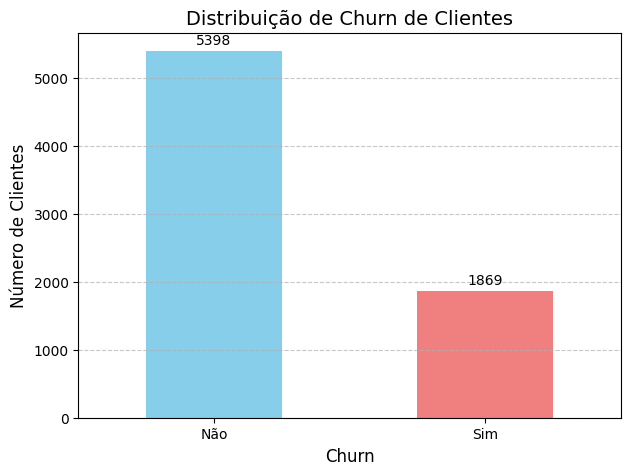

In [72]:
import matplotlib.pyplot as plt

# Criando um gráfico de barras para visualizar a proporção de churn
plt.figure(figsize=(7, 5))
churn_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Distribuição de Churn de Clientes', fontsize=14)
plt.xlabel('Churn', fontsize=12)
plt.ylabel('Número de Clientes', fontsize=12)
plt.xticks(rotation=0)

for index, value in enumerate(churn_counts):
    plt.text(index, value + 50, str(value), ha='center', va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [73]:
# Contagem de Evasão por Variáveis Categóricas
categorias_dos_clientes = [
    'Genero', 'Idoso_60+', 'Possui_Parceiro', 'Possui_Dependentes', 'Servico_Telefone',
    'Multiplas_Linhas', 'Servico_Internet', 'Seguranca_Online', 'Backup_Online',
    'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_tv', 'Streaming_Filmes',
    'Contrato', 'Fatura_Digital', 'Metodo_Pagamento'
]

for categorias in categorias_dos_clientes:
    print(f"\nChurn por {categorias}:")
    churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)

    if 'Sim' in churn_por_categoria.columns and 'Não' in churn_por_categoria.columns:
        churn_por_categoria['Proporcao_Churn_Sim'] = (churn_por_categoria['Sim'] / (churn_por_categoria['Sim'] + churn_por_categoria['Não'])).fillna(0).round(4) * 100
        print(churn_por_categoria)
    elif 'Sim' in churn_por_categoria.columns and 'Não' not in churn_por_categoria.columns:
        churn_por_categoria['Proporcao_Churn_Sim'] = (churn_por_categoria['Sim'] / churn_por_categoria['Sim']).fillna(0).round(4) * 100
        print(churn_por_categoria)
    elif 'Não' in churn_por_categoria.columns and 'Sim' not in churn_por_categoria.columns:
        churn_por_categoria['Proporcao_Churn_Sim'] = 0.0
        print(churn_por_categoria)
    else:
        print("No 'Sim' or 'Não' churn categories found for this categorias.")


Churn por Genero:
Churn       Não  Sim  Proporcao_Churn_Sim
Genero                                   
Feminino   2653  939                26.14
Masculino  2745  930                25.31

Churn por Idoso_60+:
Churn       Não   Sim  Proporcao_Churn_Sim
Idoso_60+                                 
Não        4692  1393                22.89
Sim         706   476                40.27

Churn por Possui_Parceiro:
Churn             Não   Sim  Proporcao_Churn_Sim
Possui_Parceiro                                 
Não              2549  1200                32.01
Sim              2849   669                19.02

Churn por Possui_Dependentes:
Churn                Não   Sim  Proporcao_Churn_Sim
Possui_Dependentes                                 
Não                 3543  1543                30.34
Sim                 1855   326                14.95

Churn por Servico_Telefone:
Churn              Não   Sim  Proporcao_Churn_Sim
Servico_Telefone                                 
Não                537   17

/tmp/ipykernel_350/556227610.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/556227610.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/556227610.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence th

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


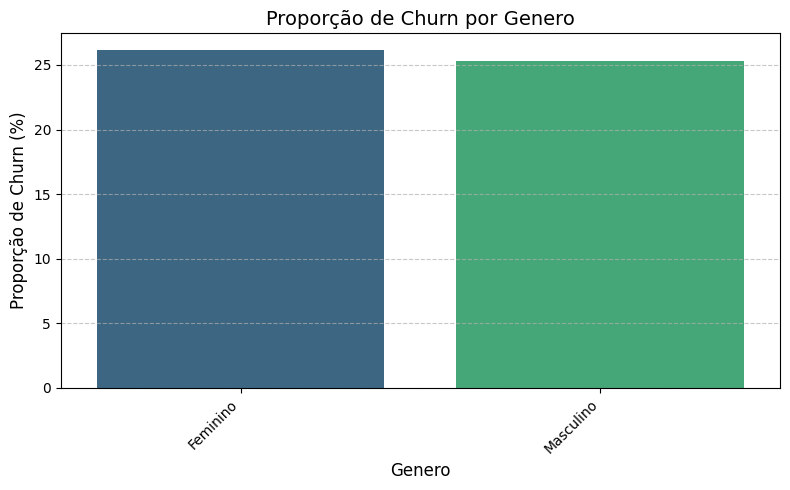

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


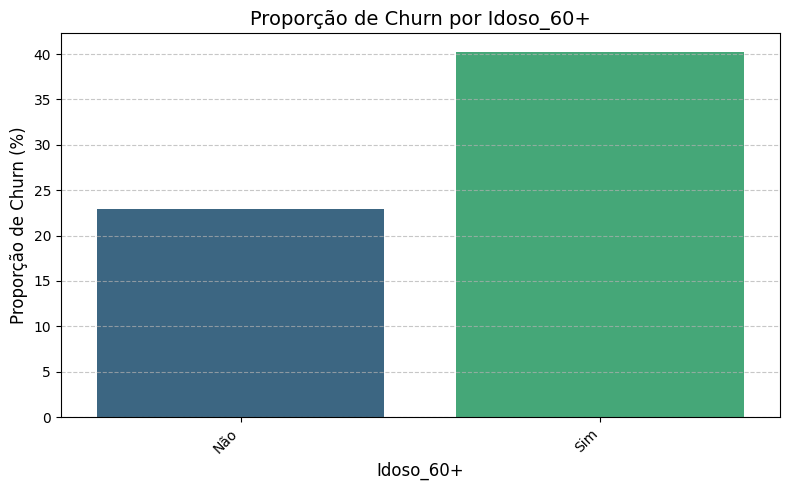

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


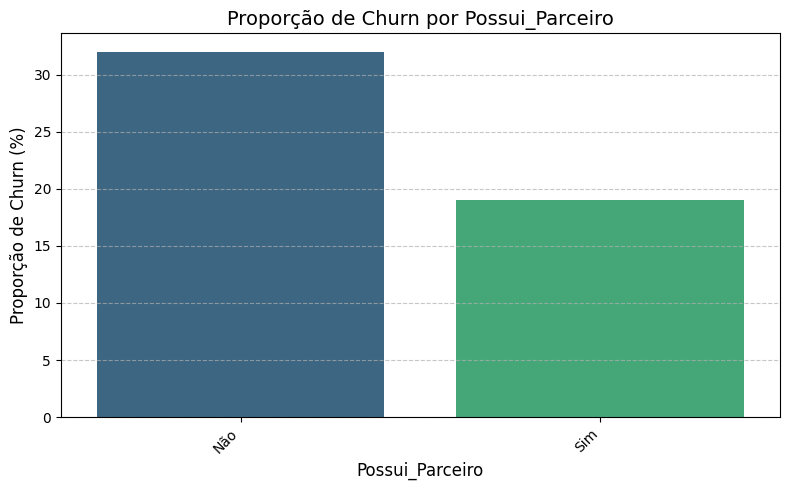

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


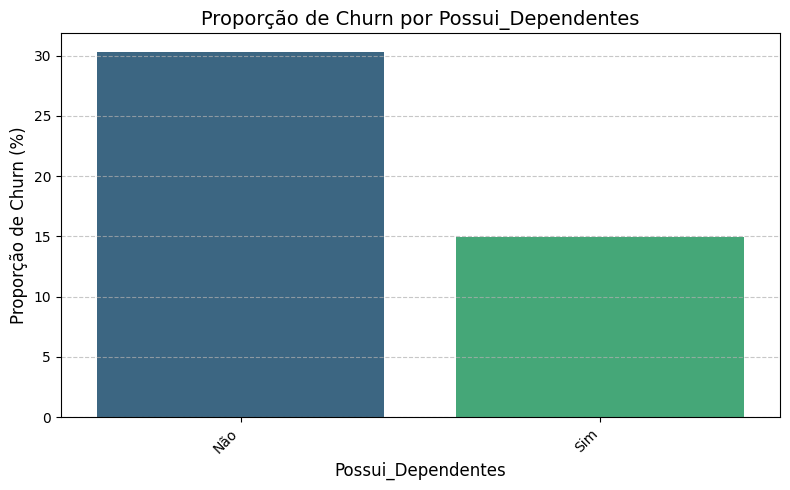

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


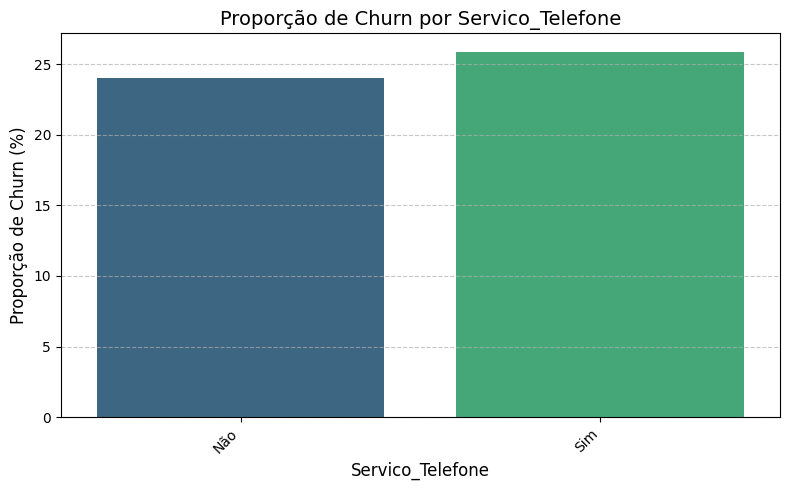

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


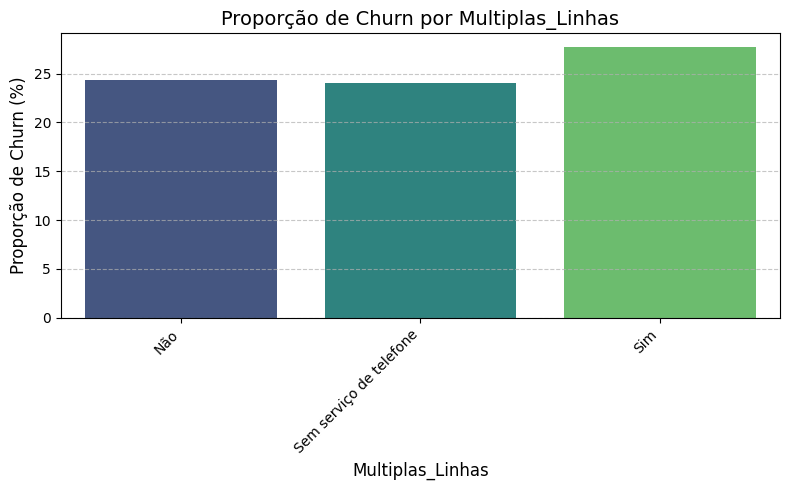

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


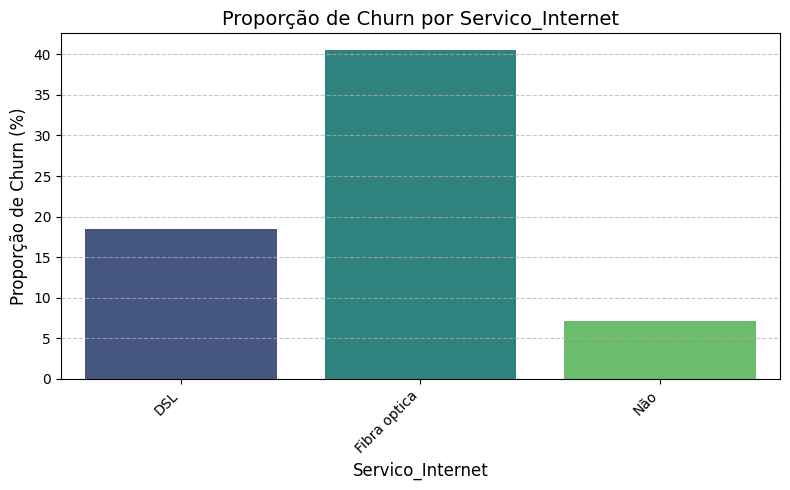

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


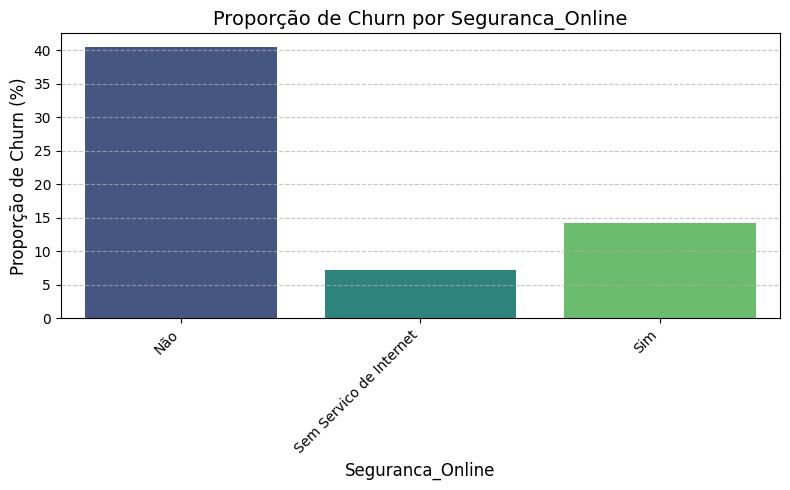

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


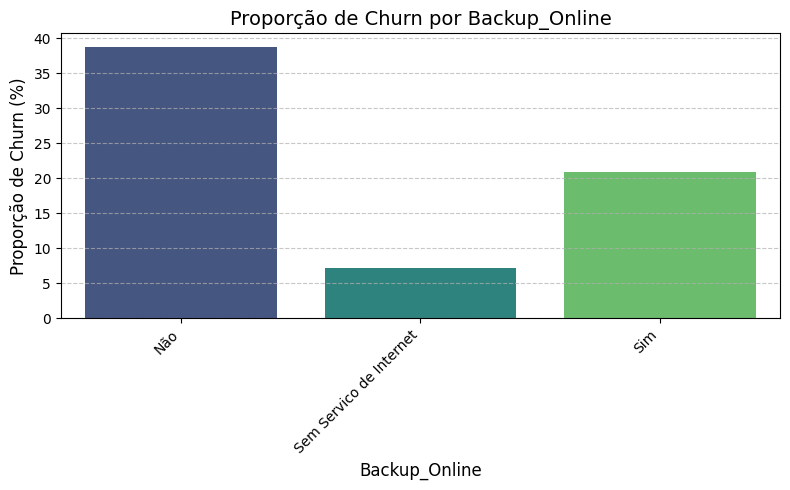

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


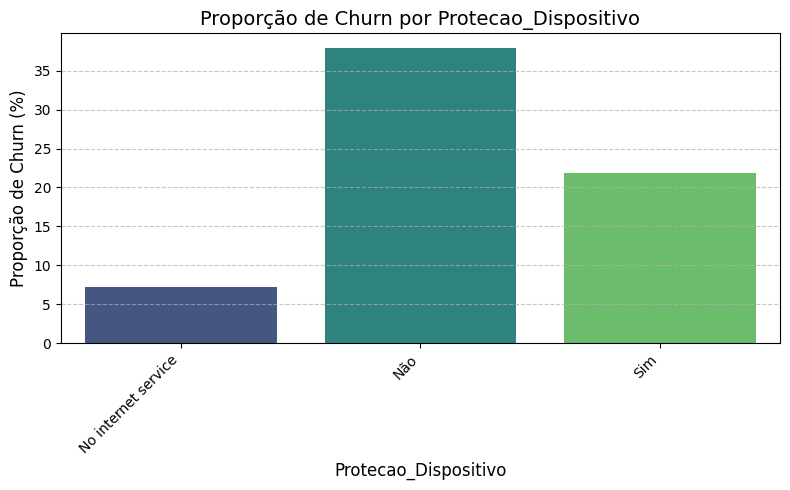

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


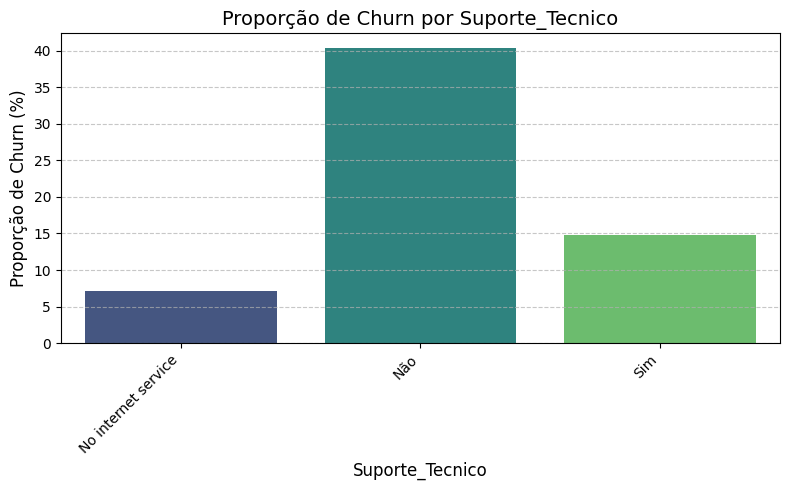

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


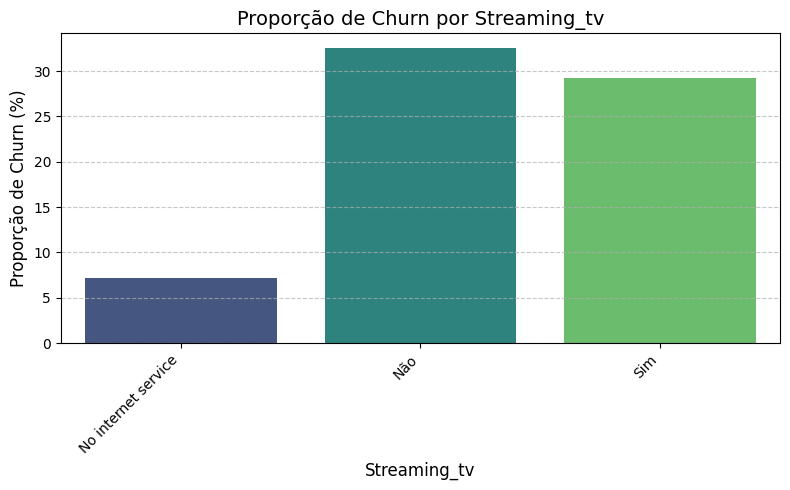

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


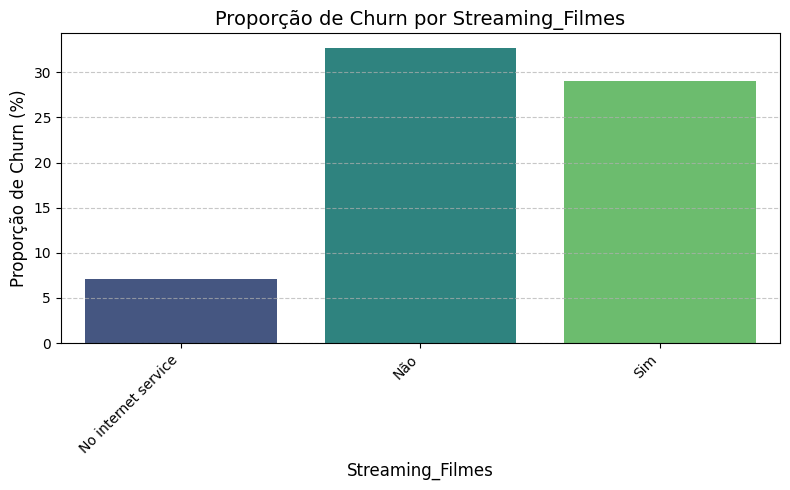

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


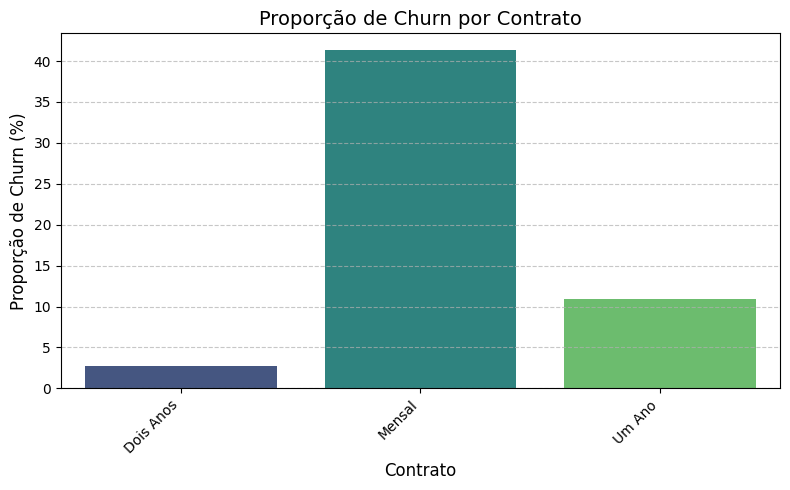

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


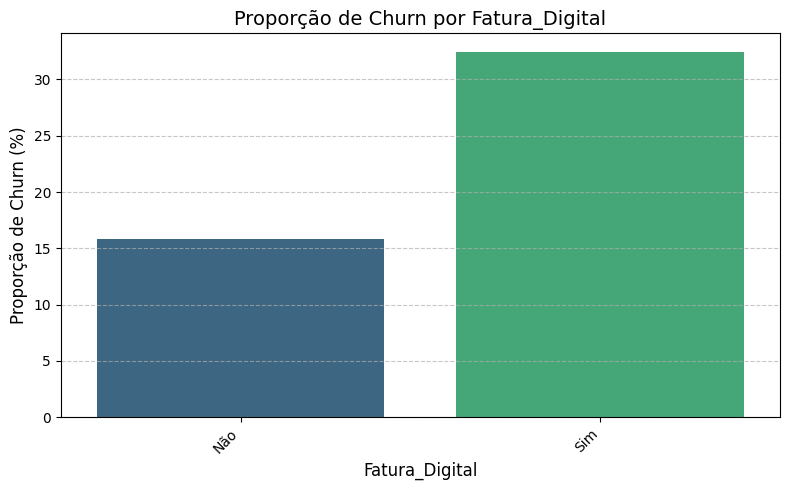

/tmp/ipykernel_350/2956972890.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/2956972890.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')


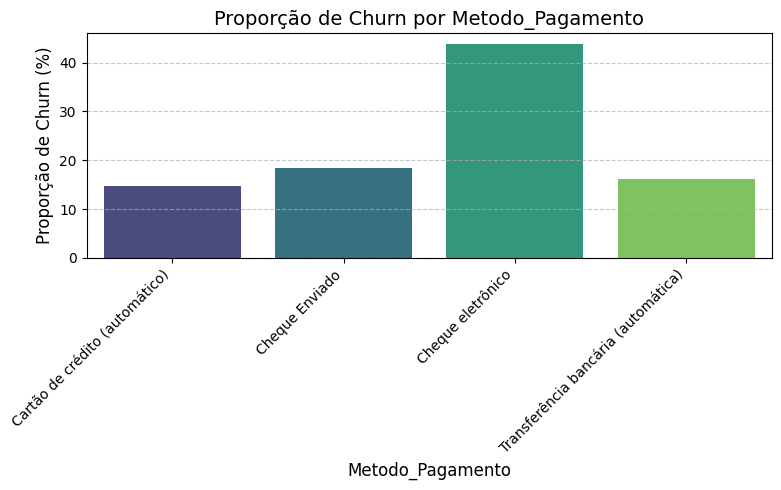

In [74]:
# Criando gráficos de barras para Contagem de Evasão por Variáveis Categóricas
import matplotlib.pyplot as plt
import seaborn as sns

categorias_dos_clientes = [
    'Genero', 'Idoso_60+', 'Possui_Parceiro', 'Possui_Dependentes', 'Servico_Telefone',
    'Multiplas_Linhas', 'Servico_Internet', 'Seguranca_Online', 'Backup_Online',
    'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_tv', 'Streaming_Filmes',
    'Contrato', 'Fatura_Digital', 'Metodo_Pagamento'
]

for categorias in categorias_dos_clientes:
    plt.figure(figsize=(8, 5))
    churn_por_categoria = df_normalized.groupby([categorias, 'Churn']).size().unstack(fill_value=0)

    if 'Sim' in churn_por_categoria.columns and 'Não' in churn_por_categoria.columns:
        churn_por_categoria['Proporcao_Churn_Sim'] = (churn_por_categoria['Sim'] / (churn_por_categoria['Sim'] + churn_por_categoria['Não'])).fillna(0) * 100
        sns.barplot(x=churn_por_categoria.index, y='Proporcao_Churn_Sim', data=churn_por_categoria, palette='viridis')
        plt.title(f'Proporção de Churn por {categorias}', fontsize=14)
        plt.xlabel(categorias, fontsize=12)
        plt.ylabel('Proporção de Churn (%)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Não há categorias 'Sim' ou 'Não' em Churn para {categorias} para plotar.")


In [75]:
# Contagem de Evasão por Variáveis Numéricas
Colunas_numericas = ['Tempo_Contrato', 'Cobranca_Mensal', 'Cobranca_Total', 'Contas_Diarias']

for col in Colunas_numericas:
    print(f"### Estatísticas Descritivas para {col} (por Churn):\n")
    print(df_normalized.groupby('Churn')[col].describe())
    print("\n\n")

/tmp/ipykernel_350/1183537274.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_normalized.groupby('Churn')[col].describe())
/tmp/ipykernel_350/1183537274.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_normalized.groupby('Churn')[col].describe())
/tmp/ipykernel_350/1183537274.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_normalized.groupby('Churn')[col].describe())
/tmp/ipykernel_3

### Estatísticas Descritivas para Tempo_Contrato (por Churn):

        count       mean        std  min   25%   50%   75%   max
Churn                                                           
Não    5398.0  37.321045  24.178367  0.0  14.0  37.0  61.0  72.0
Sim    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0



### Estatísticas Descritivas para Cobranca_Mensal (por Churn):

        count       mean        std    min    25%    50%      75%     max
Churn                                                                    
Não    5398.0  61.354224  31.105006  18.25  25.10  64.50  88.6375  118.75
Sim    1869.0  74.441332  24.666053  18.85  56.15  79.65  94.2000  118.35



### Estatísticas Descritivas para Cobranca_Total (por Churn):

        count         mean          std    min      25%       50%       75%  \
Churn                                                                         
Não    5398.0  2538.098546  2328.561578  18.80  571.075  1663.625  4237.275   
Sim    1869

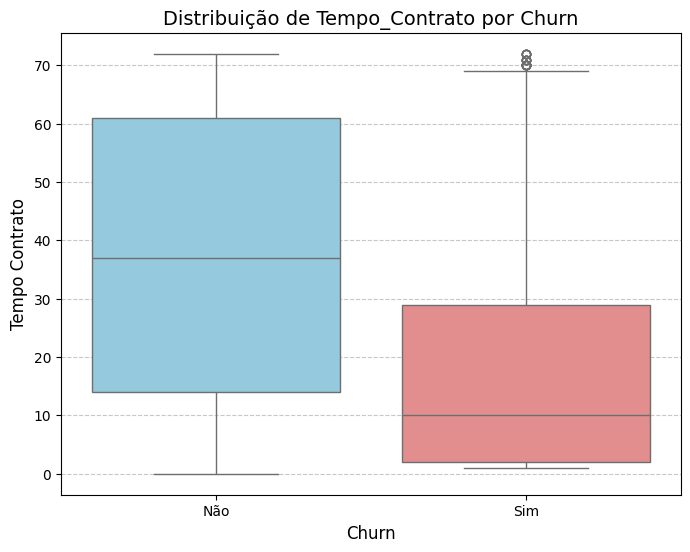

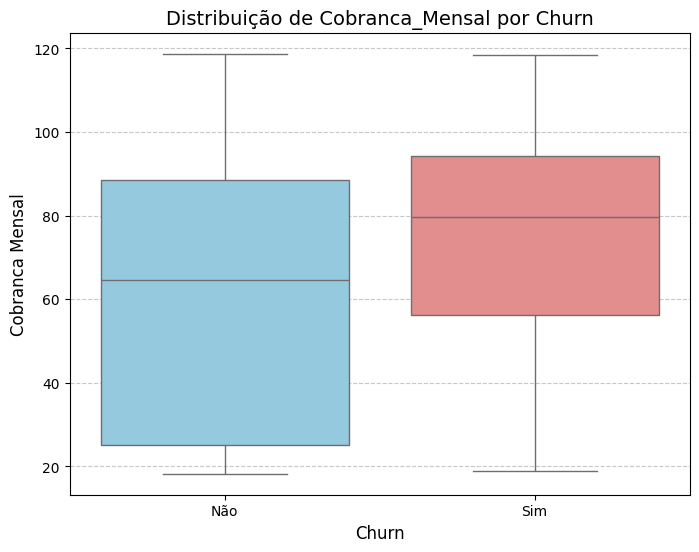

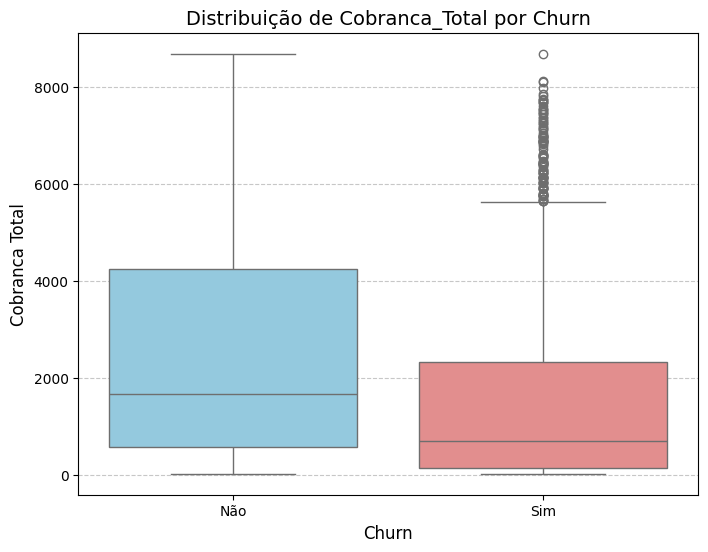

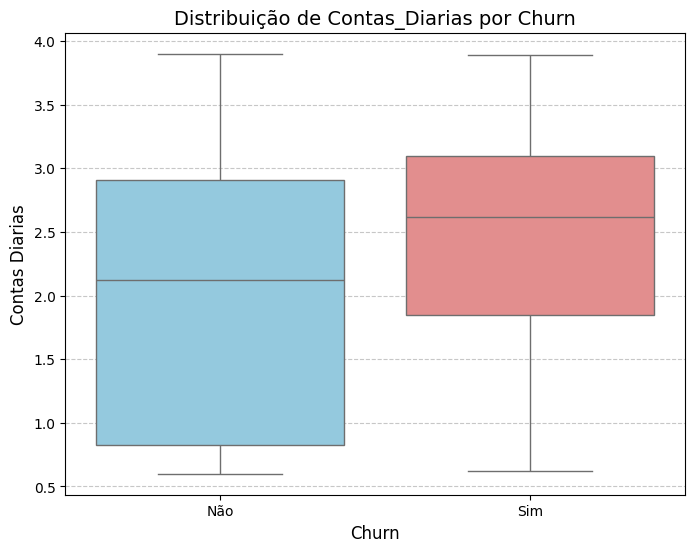

In [76]:
# Criando gráficos ilistrando a distribuição de Contagem de Evasão por Variáveis Numéricas
import matplotlib.pyplot as plt
import seaborn as sns

Colunas_numericas = ['Tempo_Contrato', 'Cobranca_Mensal', 'Cobranca_Total', 'Contas_Diarias']

for col in Colunas_numericas:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='Churn', y=col, data=df_normalized, hue='Churn', palette={'Sim': 'lightcoral', 'Não': 'skyblue'})
    plt.title(f'Distribuição de {col} por Churn', fontsize=14)
    plt.xlabel('Churn', fontsize=12)
    plt.ylabel(col.replace('_', ' '), fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

/tmp/ipykernel_350/3523941994.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_tenure = df_normalized.groupby(['Tempo_Contrato', 'Churn']).size().unstack(fill_value=0)
/tmp/ipykernel_350/3523941994.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=churn_by_tenure.index, y='Proporcao_Churn_Sim', data=churn_by_tenure, palette='coolwarm_r')


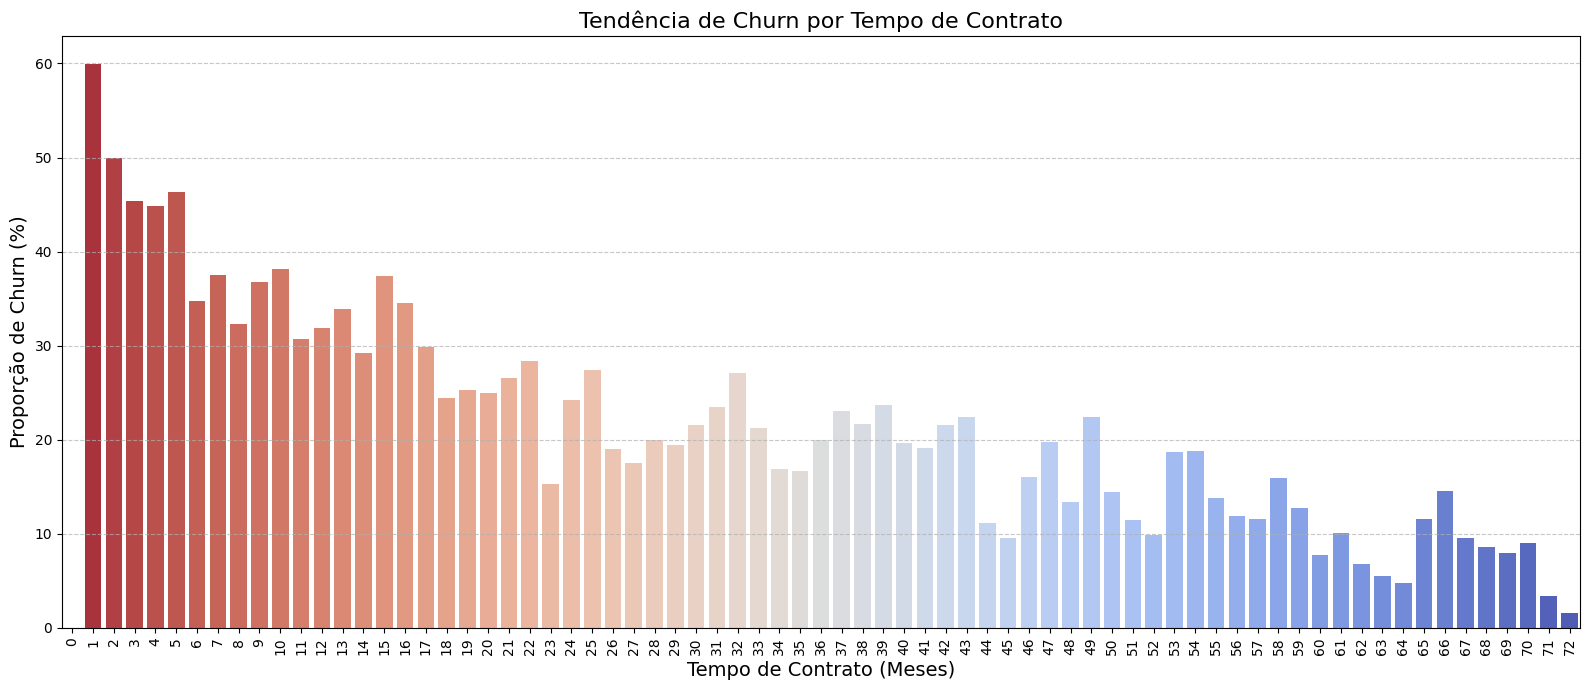

In [77]:
# Criando gráfico de barras indicando a tendencia de churn por tempo de contrato

import matplotlib.pyplot as plt
import seaborn as sns

churn_by_tenure = df_normalized.groupby(['Tempo_Contrato', 'Churn']).size().unstack(fill_value=0)

churn_by_tenure['Proporcao_Churn_Sim'] = (churn_by_tenure['Sim'] / (churn_by_tenure['Sim'] + churn_by_tenure['Não'])).fillna(0) * 100

plt.figure(figsize=(16, 7))
sns.barplot(x=churn_by_tenure.index, y='Proporcao_Churn_Sim', data=churn_by_tenure, palette='coolwarm_r')
plt.title('Tendência de Churn por Tempo de Contrato', fontsize=16)
plt.xlabel('Tempo de Contrato (Meses)', fontsize=14)
plt.ylabel('Proporção de Churn (%)', fontsize=14)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#📄Relatorio Final

# Relatório Detalhado de Análise de Churn de Clientes

## 1. Introdução
Este relatório apresenta uma análise detalhada da taxa de *churn* (evasão de clientes) de uma empresa de telecomunicações, baseando-se no conjunto de dados `TelecomX_Data.json`. O objetivo principal é identificar os principais fatores que contribuem para a evasão de clientes, fornecendo *insights* acionáveis e recomendações para a retenção de clientes.

## 2. Limpeza e Tratamento de Dados
A fase de limpeza e tratamento de dados envolveu as seguintes etapas:
*   **Extração e Normalização**: Os dados, inicialmente em formato JSON aninhado, foram extraídos e normalizados em um único DataFrame (`df_normalized`) para facilitar a análise. Colunas aninhadas como 'customer', 'phone', 'internet' e 'account' foram expandidas.
*   **Verificação de Valores Nulos e Duplicados**: Foi verificado que não havia valores nulos evidentes inicialmente, nem linhas duplicadas. No entanto, uma verificação mais aprofundada revelou:
    *   11 valores em branco na coluna `Charges.Total`.
    *   224 valores em branco na coluna `Churn`.
*   **Tratamento de Tipos de Dados**:
    *   A coluna `Charges.Total` foi identificada como tipo 'object' e convertida para 'float'. Os valores em branco que resultaram em `NaN` durante a conversão foram preenchidos com a mediana da coluna para evitar distorções por valores extremos.
    *   Os valores em branco na coluna `Churn` foram substituídos por `NaN` e, posteriormente, preenchidos com a moda da coluna ('Não'), considerando que a maioria dos clientes não realiza *churn*. A coluna `Churn` foi convertida para tipo 'category'.
*   **Criação de Novas Features**: Uma nova coluna, `Contas_Diarias`, foi criada dividindo `Cobranca_Mensal` pela média de dias em um mês contando com o ano bissexto a cada quatro anos (30.4375) para uma perspectiva diária de gastos.
*   **Renomeação e Padronização de Colunas e Valores**: As colunas foram renomeadas para termos mais claros e em português (ex: `customerID` para `ID`, `gender` para `Genero`). Além disso, os valores nas colunas categóricas foram padronizados para termos em português (ex: 'Yes' para 'Sim', 'No' para 'Não', 'Female' para 'Feminino', 'Male' para 'Masculino').

## 3. Análise Exploratória de Dados
A análise exploratória revelou a distribuição geral do *churn* e a relação com diversas variáveis categóricas e numéricas.

### 3.1. Distribuição Geral de Churn
A análise inicial da coluna `Churn` mostrou que:
*   **5398 clientes** (74.28%) não realizaram *churn*.
*   **1869 clientes** (25.72%) realizaram *churn*.
Esta proporção indica que a evasão é um problema significativo, afetando aproximadamente um quarto da base de clientes. A visualização desta distribuição foi feita através de um gráfico de barras.

### 3.2. Churn por Variáveis Categóricas
A análise de *churn* por categorias chave destacou os seguintes pontos principais:
*   **Idoso_60+**: Clientes idosos (`Idoso_60+ = Sim`) têm uma taxa de churn significativamente maior (40.27%) em comparação com clientes não idosos (22.89%).
*   **Possui_Parceiro/Possui_Dependentes**: Clientes sem parceiro (32.01%) e sem dependentes (30.34%) apresentam taxas de churn mais altas.
*   **Servico_Internet**: Clientes com serviço de internet "Fibra optica" têm a maior taxa de churn (40.56%), enquanto aqueles sem serviço de internet ('Não') têm a menor (7.15%).
*   **Serviços Adicionais (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport)**: Clientes que *não* possuem serviços adicionais mostram taxas de *churn* mais elevadas. Por outro lado, aqueles que não têm serviço de internet ('Sem Servico de Internet') para estes itens têm uma taxa de churn muito menor, e clientes que *possuem* esses serviços têm taxas menores que a média global.
*   **Contrato**: Clientes com contrato "Mensal" têm uma taxa de *churn* alarmantemente alta (41.32%) em comparação com contratos de "Um Ano" (10.93%) e "Dois Anos" (2.75%).
*   **Fatura_Digital**: Clientes que optam pela "Fatura_Digital" (32.48%) têm uma taxa de *churn* maior do que aqueles que não a utilizam (15.87%).
*   **Metodo_Pagamento**: O método de pagamento "Cheque eletrônico" está associado à maior taxa de *churn* (43.80%).

### 3.3. Churn por Variáveis Numéricas
A análise das variáveis numéricas (`Tempo_Contrato`, `Cobranca_Mensal`, `Cobranca_Total`, `Contas_Diarias`) em relação ao *churn* forneceu *insights* valiosos.

#### Sumário das Observações sobre Churn e Variáveis Numéricas
*   **Tempo_Contrato**: Clientes que não churnaram tendem a ter um tempo de contrato significativamente maior (média de 37 meses) em comparação com clientes que churnaram (média de 18 meses).
*   **Cobranca_Mensal**: Clientes que churnaram apresentam uma cobrança mensal média ligeiramente maior (74.44) do que clientes que não churnaram (61.35).
*   **Cobranca_Total**: Clientes que não churnaram têm uma cobrança total média significativamente mais alta (2538.10) do que clientes que churnaram (1531.80).
*   **Contas_Diarias**: Similar à 'Cobranca_Mensal', as `Contas_Diarias` também são ligeiramente maiores para clientes que churnaram (média de 2.45) em comparação com clientes que não churnaram (média de 2.02).

**Em resumo:** Clientes que churnam tendem a ter um *tempo de contrato mais curto*, mas pagam *cobranças mensais e diárias ligeiramente mais altas*. Clientes leais (que não churnam) permanecem por mais tempo e, consequentemente, acumulam cobranças totais muito maiores. Isso sugere que fatores relacionados ao custo-benefício dos serviços mensais e a duração do relacionamento com a empresa são fortes indicadores de churn.

## 4. Conclusões e Insights
A análise revelou que o perfil do cliente propenso ao *churn* é complexo, mas alguns padrões claros emergiram:
*   **Duração do Contrato:** Clientes com contratos mensais são significativamente mais propensos a churnar. Contratos mais longos demonstram uma forte relação com a retenção.
*   **Serviços de Internet e Adicionais:** A "Fibra Óptica" está associada a uma alta taxa de *churn*. A ausência de serviços de segurança (Segurança Online, Backup, Proteção de Dispositivo, Suporte Técnico) aumenta drasticamente a probabilidade de *churn*.
*   **Custos Mensais:** Clientes com cobranças mensais mais altas são um pouco mais propensos a churnar.
*   **Método de Pagamento:** O "Cheque eletrônico" é um método de pagamento associado a uma alta taxa de *churn*.
*   **Demografia:** Clientes idosos, sem parceiros e sem dependentes mostram maior propensão à evasão.

## 5. Recomendações
Com base nos *insights* obtidos, as seguintes recomendações são propostas para reduzir a taxa de *churn*:

1.  **Incentivar Contratos de Longo Prazo**:
    *   Oferecer descontos progressivos ou benefícios exclusivos para clientes que optam por contratos de 1 ou 2 anos.
    *   Criar programas de fidelidade que recompensem a permanência do cliente.
    *   Comunicar claramente os benefícios e a economia a longo prazo de contratos estendidos.

2.  **Melhorar a Proposta de Valor da Fibra Óptica**:
    *   Investigar os motivos específicos de *churn* para clientes de fibra óptica (qualidade do serviço, suporte, preço).
    *   Oferecer pacotes mais atraentes ou serviços adicionais gratuitos para clientes de fibra óptica.

3.  **Promover e Integrar Serviços de Segurança e Suporte**:
    *   Campanhas de marketing que destaquem os benefícios da Segurança Online, Backup, Proteção do Dispositivo e Suporte Técnico.
    *   Considerar a inclusão de serviços básicos de segurança ou suporte técnico em pacotes de internet.

4.  **Otimizar a Estratégia de Preços e Pacotes**:
    *   Reavaliar a estrutura de preços dos serviços, especialmente para pacotes com Cobranca Mensal mais alta.
    *   Oferecer opções de pacotes mais flexíveis ou personalizados.

5.  **Monitorar Clientes com "Cheque Eletrônico"**:
    *   Identificar se há problemas com o processo de "Cheque eletrônico", se este método de pagamento é preferido por um segmento de clientes mais propenso a *churn* ou analisar se este método já é ultrapassado e deveria ser substituído.
    *   Considerar incentivar outros métodos de pagamento mais estáveis e automáticos.

6.  **Programas Direcionados para Idosos e Clientes Sem Vínculos**:
    *   Desenvolver pacotes ou serviços específicos para clientes idosos, solteiros ou sem dependentes.
    *   Oferecer suporte ao cliente mais personalizado para esses segmentos.

Essas recomendações visam não apenas reduzir o *churn* existente, mas também construir um relacionamento mais sólido e duradouro com a base de clientes da TelecomX.